In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
#load dataset
df = pd.read_excel("Cleaned_Dataset.xlsx")

In [4]:
#first 5 rows
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9551 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

In [6]:
#Understand the Target Variable
df["Aggregate rating"].head()

0    4.8
1    4.5
2    4.4
3    4.9
4    4.8
Name: Aggregate rating, dtype: float64

In [7]:
#Select Features
features = [
    "Average Cost for two",
    "Price range",
    "Votes",
    "Has Table booking",
    "Has Online delivery",
    "Country Code",
    "City",
    "Cuisines"
]

X = df[features]
y = df["Aggregate rating"]

In [8]:
#diplay features
X.head()

,Average Cost for two,Price range,Votes,Has Table booking,Has Online delivery,Country Code,City,Cuisines
0,1100,3,314,Yes,No,162,Makati City,"French, Japanese, Desserts"
1,1200,3,591,Yes,No,162,Makati City,Japanese
2,4000,4,270,Yes,No,162,Mandaluyong City,"Seafood, Asian, Filipino, Indian"
3,1500,4,365,No,No,162,Mandaluyong City,"Japanese, Sushi"
4,1500,4,229,Yes,No,162,Mandaluyong City,"Japanese, Korean"


In [11]:
X = df[features].copy()

In [12]:
#Encode Categorical Variables
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

categorical_columns = [
    "Has Table booking",
    "Has Online delivery",
    "City",
    "Cuisines"
]

for column in categorical_columns:
    X[column] = label_encoder.fit_transform(X[column])

In [10]:
X.head()

,Average Cost for two,Price range,Votes,Has Table booking,Has Online delivery,Country Code,City,Cuisines
0,1100,3,314,1,0,162,73,920
1,1200,3,591,1,0,162,73,1111
2,4000,4,270,1,0,162,75,1671
3,1500,4,365,0,0,162,75,1126
4,1500,4,229,1,0,162,75,1122


In [13]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Average Cost for two  9551 non-null   int64
 1   Price range           9551 non-null   int64
 2   Votes                 9551 non-null   int64
 3   Has Table booking     9551 non-null   int32
 4   Has Online delivery   9551 non-null   int32
 5   Country Code          9551 non-null   int64
 6   City                  9551 non-null   int32
 7   Cuisines              9551 non-null   int32
dtypes: int32(4), int64(4)
memory usage: 447.8 KB


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
#check shape

print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)
print("Training Labels:", y_train.shape)
print("Testing Labels:", y_test.shape)

Training Features: (7640, 8)
Testing Features: (1911, 8)
Training Labels: (7640,)
Testing Labels: (1911,)


In [16]:
#random forest model

from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [18]:
#make predictions

y_pred = model.predict(X_test)
print(y_pred)

[3.348   2.888   3.00725 ... 3.024   4.141   4.173  ]


In [19]:
#view some predictions

prediction_df = pd.DataFrame({
    "Actual Rating": y_test.values,
    "Predicted Rating": y_pred
})

prediction_df.head(10)

,Actual Rating,Predicted Rating
0,2.1,3.348000
1,4.1,2.888000
2,3.2,3.007250
3,4.4,3.788000
4,3.5,3.108367
5,0.0,0.000000
6,3.2,3.170000
7,0.0,0.000000
8,3.6,3.182000
9,4.0,3.674667


In [20]:
#Evaluate the Model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [21]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", round(mae, 3))
print("Mean Squared Error (MSE):", round(mse, 3))
print("Root Mean Squared Error (RMSE):", round(rmse, 3))
print("R² Score:", round(r2, 3))

Mean Absolute Error (MAE): 0.206
Mean Squared Error (MSE): 0.101
Root Mean Squared Error (RMSE): 0.318
R² Score: 0.955


In [22]:
#Feature Importance
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
2,Votes,0.954303
7,Cuisines,0.015347
0,Average Cost for two,0.009948
5,Country Code,0.008272
6,City,0.007423
4,Has Online delivery,0.002093
1,Price range,0.001710
3,Has Table booking,0.000902


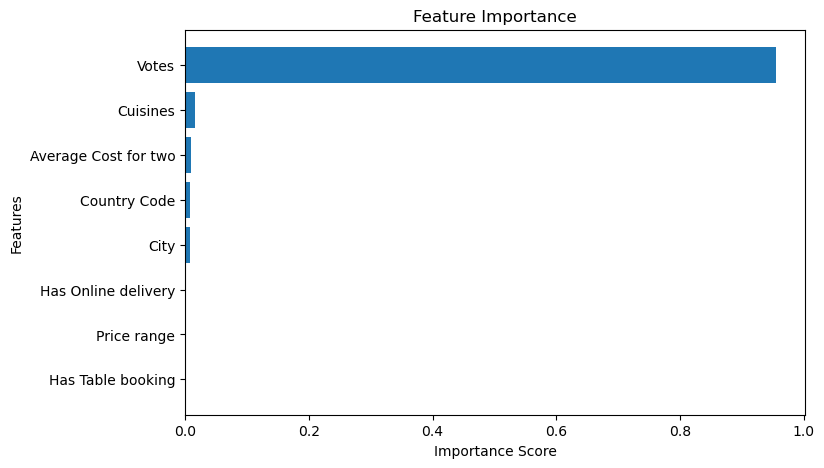

In [23]:
#Visualize Feature Importance
plt.figure(figsize=(8,5))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.gca().invert_yaxis()

plt.show()

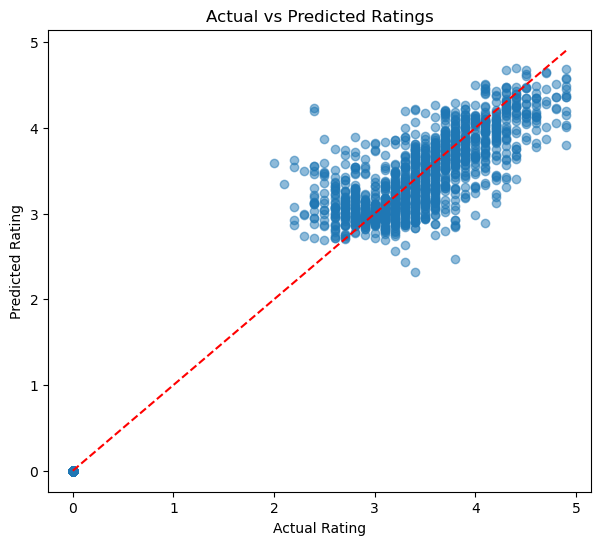

In [24]:
#Actual vs Predicted Ratings
plt.figure(figsize=(7,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

plt.plot(
    [y.min(), y.max()],
    [y.min(), y.max()],
    'r--'
)

plt.title("Actual vs Predicted Ratings")
plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")

plt.show()

# Observations

- A Random Forest Regressor was trained to predict restaurant aggregate ratings.
- The model was evaluated using MAE, MSE, RMSE, and R² Score.
- Feature importance analysis identified the variables that contributed most to the prediction.
- The Actual vs Predicted plot shows how closely the model's predictions match the true ratings.
- This predictive model can help estimate restaurant ratings based on their characteristics.

# Level 3 - Task 2
## Customer Preference Analysis

In [25]:
#Find the Most Popular Cuisines
top_cuisines = df["Cuisines"].value_counts().head(10)

print(top_cuisines)

Cuisines
North Indian                      936
North Indian, Chinese             511
Chinese                           354
Fast Food                         354
North Indian, Mughlai             334
Cafe                              299
Bakery                            218
North Indian, Mughlai, Chinese    197
Bakery, Desserts                  170
Street Food                       149
Name: count, dtype: int64


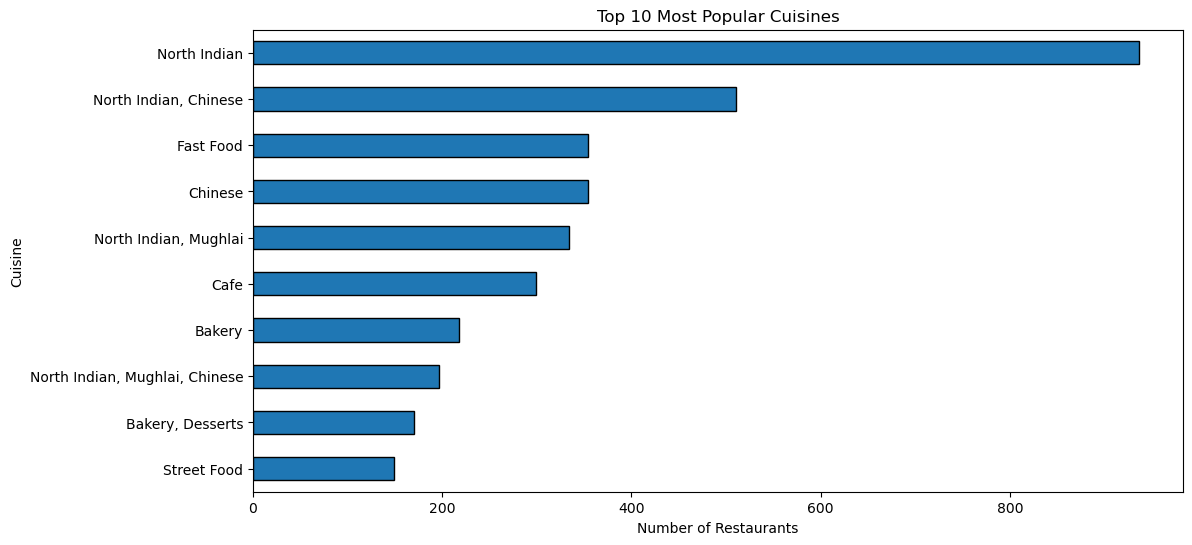

In [26]:
#Visualize the Top Cuisines
plt.figure(figsize=(12,6))

top_cuisines.sort_values().plot(
    kind="barh",
    edgecolor="black"
)

plt.title("Top 10 Most Popular Cuisines")
plt.xlabel("Number of Restaurants")
plt.ylabel("Cuisine")

plt.show()

In [ ]:
#Average Rating by Cuisine
top_cuisines = df["Cuisines"].value_counts().head(10).index
top_cuisine_df = df[df["Cuisines"].isin(top_cuisines)]

popular_cuisine_rating = (
    df[df["Cuisines"].isin(top_cuisines)]
    .groupby("Cuisines")["Aggregate rating"]
    .mean()
    .sort_values()
)

print(popular_cuisine_rating)

Cuisines
North Indian                      1.672329
Bakery                            1.924312
Chinese                           2.042090
Fast Food                         2.118362
Street Food                       2.161745
Bakery, Desserts                  2.317647
North Indian, Chinese             2.421722
North Indian, Mughlai, Chinese    2.568528
North Indian, Mughlai             2.888623
Cafe                              2.890970
Name: Aggregate rating, dtype: float64


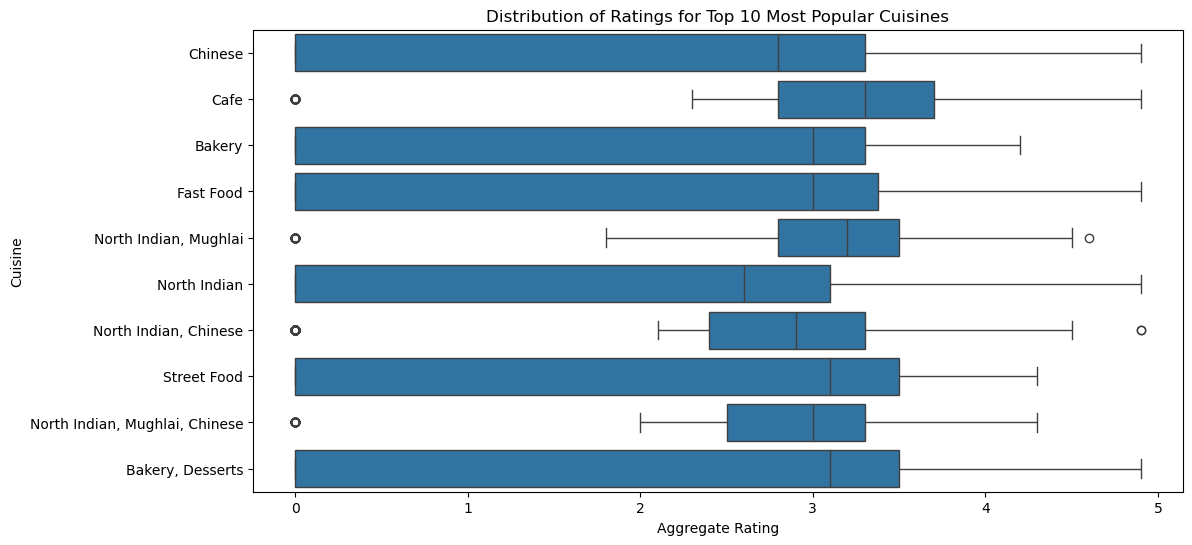

In [ ]:
#Visualize Cuisine Ratings
plt.figure(figsize=(12,6))

sns.boxplot(
    x="Aggregate rating",
    y="Cuisines",
    data=top_cuisine_df
)

plt.title("Distribution of Ratings for Top 10 Most Popular Cuisines")
plt.xlabel("Aggregate Rating")
plt.ylabel("Cuisine")

plt.show()

In [35]:
#Relationship Between Votes and Ratings
correlation = df["Votes"].corr(df["Aggregate rating"])

print("Correlation between Votes and Ratings:", round(correlation,3))

Correlation between Votes and Ratings: 0.314


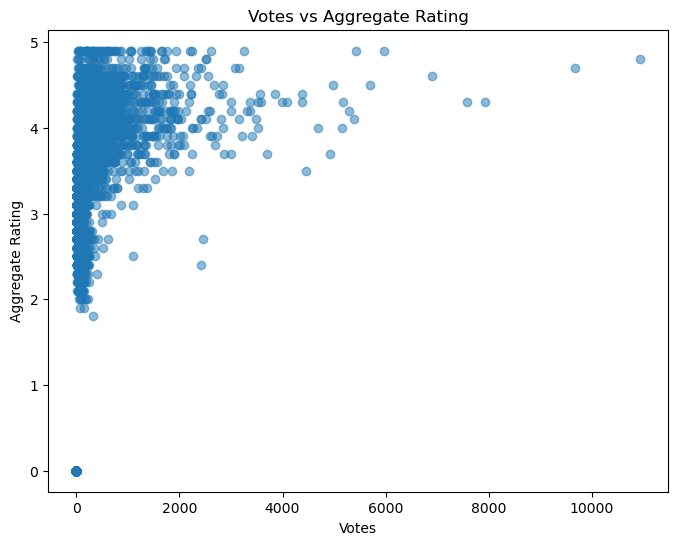

In [36]:
#Visualize Votes vs Ratings
plt.figure(figsize=(8,6))

plt.scatter(
    df["Votes"],
    df["Aggregate rating"],
    alpha=0.5
)

plt.title("Votes vs Aggregate Rating")
plt.xlabel("Votes")
plt.ylabel("Aggregate Rating")

plt.show()

In [37]:
#Top 10 Restaurants by Votes
top_votes = df.nlargest(10, "Votes")

top_votes[["Restaurant Name", "Votes", "Aggregate rating"]]

,Restaurant Name,Votes,Aggregate rating
728,Toit,10934,4.8
735,Truffles,9667,4.7
3994,Hauz Khas Social,7931,4.3
2412,Peter Cat,7574,4.3
739,AB's - Absolute Barbecues,6907,4.6
2414,Barbeque Nation,5966,4.9
743,Big Brewsky,5705,4.5
2307,AB's - Absolute Barbecues,5434,4.9
736,The Black Pearl,5385,4.1
2411,BarBQ,5288,4.2


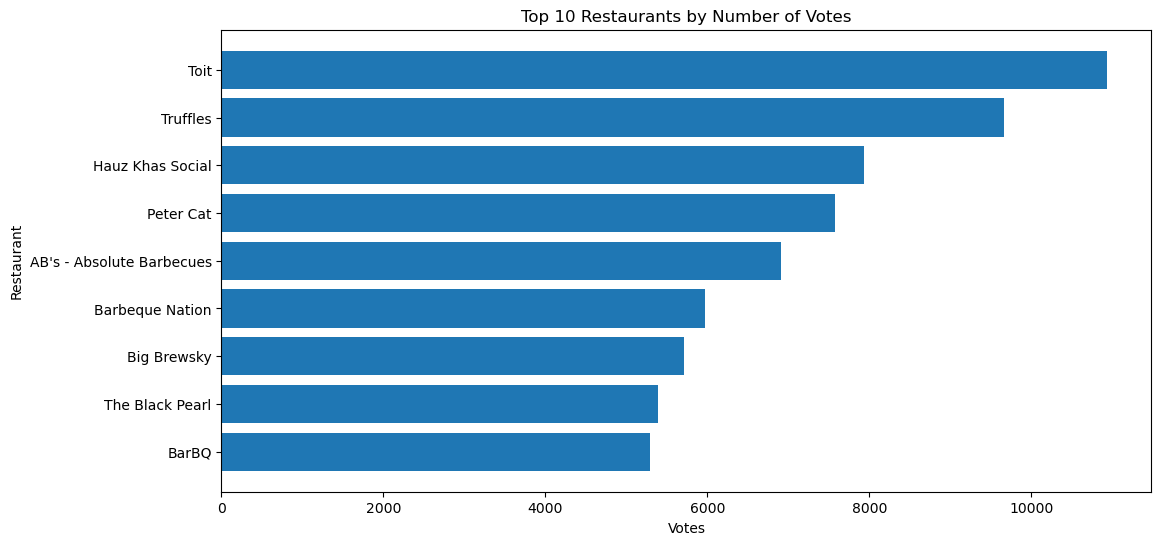

In [38]:
#Visualize Top Restaurants by Votes
plt.figure(figsize=(12,6))

plt.barh(
    top_votes["Restaurant Name"],
    top_votes["Votes"]
)

plt.title("Top 10 Restaurants by Number of Votes")
plt.xlabel("Votes")
plt.ylabel("Restaurant")

plt.gca().invert_yaxis()

plt.show()

# Observations

- The most popular cuisines were identified based on the number of restaurants.
- The average ratings of the top cuisines were compared.
- The relationship between customer votes and aggregate ratings was analyzed.
- Restaurants with a higher number of votes generally tend to have higher ratings, although exceptions may exist.
- These findings provide insights into customer preferences and restaurant popularity.

# Level 3 - Task 3
## Data Visualization

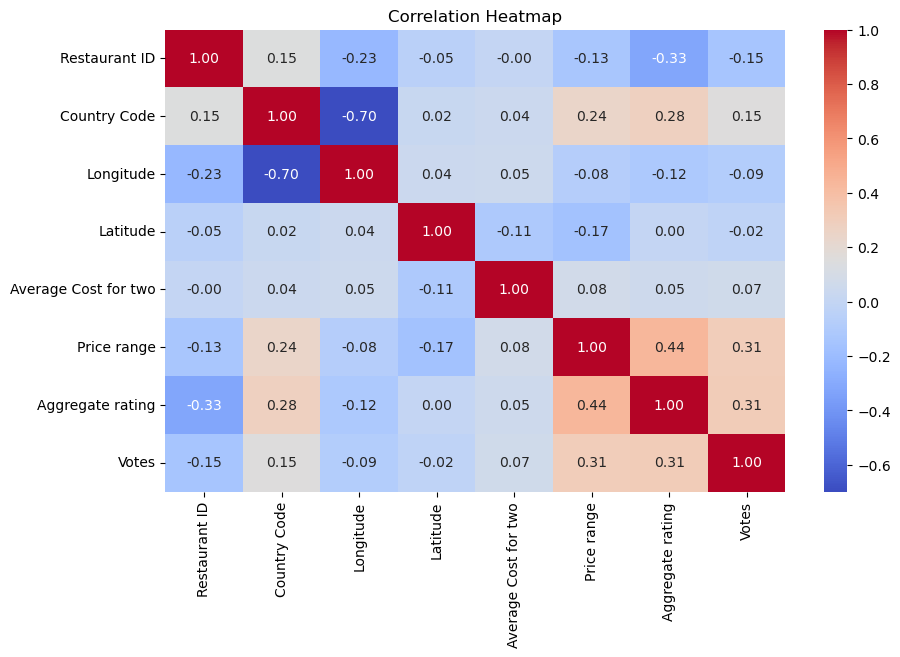

In [39]:
#Correlation Heatmap

#This gives an overview of relationships between numerical variables.

plt.figure(figsize=(10,6))

sns.heatmap(
    df.select_dtypes(include=['number']).corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

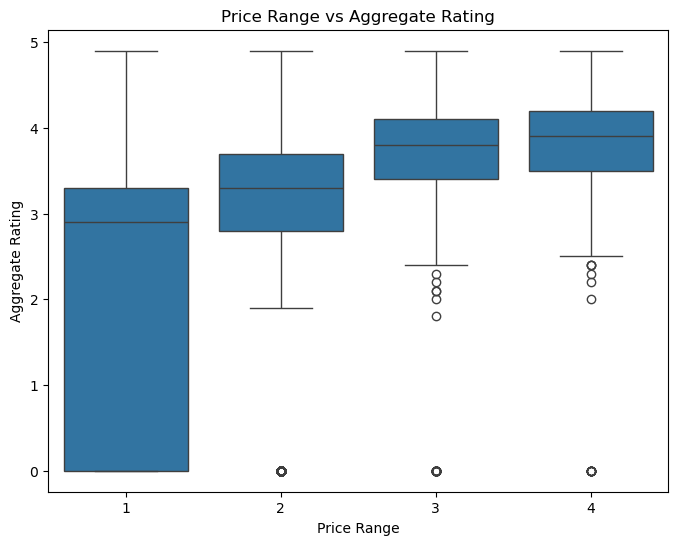

In [40]:
#Price Range vs Aggregate Rating (Box Plot)
plt.figure(figsize=(8,6))

sns.boxplot(
    x="Price range",
    y="Aggregate rating",
    data=df
)

plt.title("Price Range vs Aggregate Rating")
plt.xlabel("Price Range")
plt.ylabel("Aggregate Rating")

plt.show()

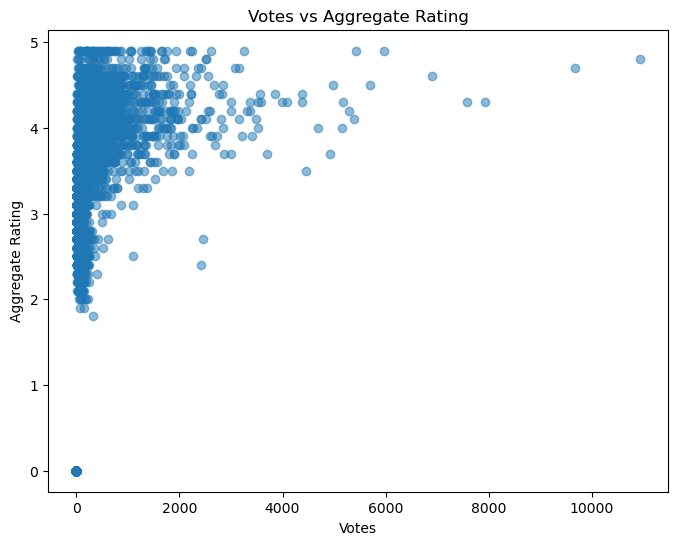

In [41]:
#Votes vs Aggregate Rating (Scatter Plot)
plt.figure(figsize=(8,6))

plt.scatter(
    df["Votes"],
    df["Aggregate rating"],
    alpha=0.5
)

plt.title("Votes vs Aggregate Rating")
plt.xlabel("Votes")
plt.ylabel("Aggregate Rating")

plt.show()

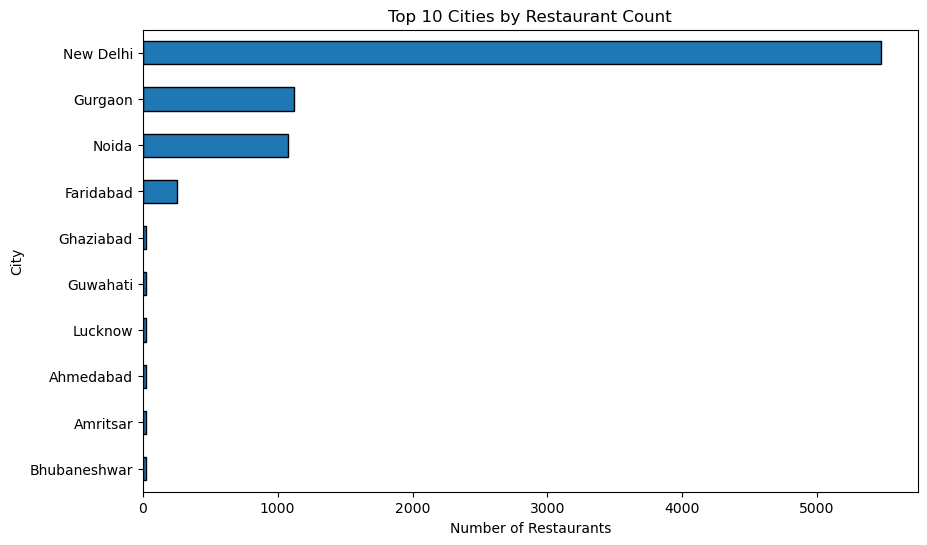

In [42]:
#Top 10 Cities by Restaurant Count
top_cities = df["City"].value_counts().head(10)

plt.figure(figsize=(10,6))

top_cities.sort_values().plot(
    kind="barh",
    edgecolor="black"
)

plt.title("Top 10 Cities by Restaurant Count")
plt.xlabel("Number of Restaurants")
plt.ylabel("City")

plt.show()

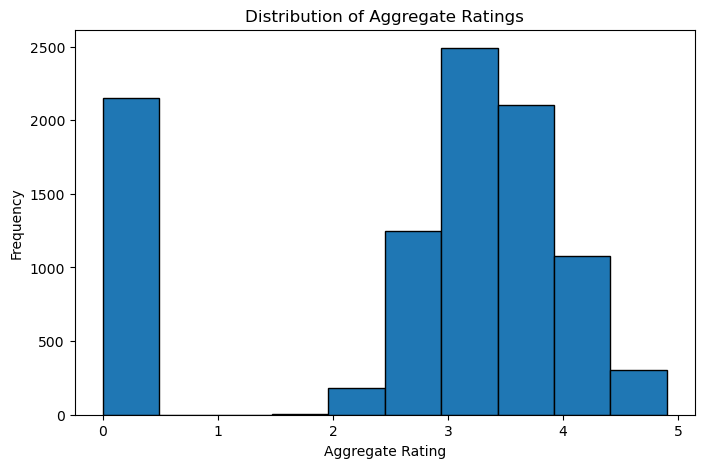

In [43]:
#Distribution of Aggregate Ratings
plt.figure(figsize=(8,5))

plt.hist(
    df["Aggregate rating"],
    bins=10,
    edgecolor="black"
)

plt.title("Distribution of Aggregate Ratings")
plt.xlabel("Aggregate Rating")
plt.ylabel("Frequency")

plt.show()

# Observations

- The correlation heatmap provides an overview of relationships between numerical features.
- The box plot shows how aggregate ratings vary across different price ranges.
- The scatter plot indicates the relationship between customer votes and restaurant ratings.
- The city distribution highlights the locations with the highest concentration of restaurants.
- The histogram shows that restaurant ratings are not uniformly distributed, with some rating ranges occurring more frequently than others.
- These visualizations make it easier to identify patterns, trends, and relationships in the restaurant dataset.